# YouTube Comment Analysis - @aleksgornik

This notebook analyzes comment threads scraped from the **Aleks Gornik** YouTube channel (`@aleksgornik`). 
The goal of this analysis is to identify:
1. What types of questions and topics students ask about the most.
2. Which videos generate the most interaction and questions.
3. How to structure our AI Aleks Knowledge Base (RAG) to effectively answer these student queries.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load classified comments
classified_file = "data/classified_comments.json"
if not os.path.exists(classified_file):
    print(f"Error: {classified_file} not found. Please run analyze_comments.py first.")
else:
    with open(classified_file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    df = pd.DataFrame(data)
    print(f"Successfully loaded {len(df)} classified comments across {df['video_id'].nunique()} videos.")

Successfully loaded 1410 classified comments across 77 videos.


In [2]:
# Display overall stats
total_comments = len(df)
questions = df[df["is_question"] == True]
num_questions = len(questions)
pct_questions = (num_questions / total_comments) * 100

print("--- GENERAL STATISTICS ---")
print(f"Total comments analyzed: {total_comments}")
print(f"Comments classified as questions: {num_questions} ({pct_questions:.2f}%)")
print(f"Comments classified as feedback/praise/chatter: {total_comments - num_questions} ({100 - pct_questions:.2f}%)")

print("\n--- COMMENT DISTRIBUTION BY CATEGORY ---")
print(df["category"].value_counts())

print("\n--- QUESTIONS DISTRIBUTION BY CATEGORY ---")
print(questions["category"].value_counts())

--- GENERAL STATISTICS ---
Total comments analyzed: 1410
Comments classified as questions: 324 (22.98%)
Comments classified as feedback/praise/chatter: 1086 (77.02%)

--- COMMENT DISTRIBUTION BY CATEGORY ---
category
University & Major    404
Other                 330
Feedback & Praise     258
Career Advice         232
Study & Exams         120
Coding & Tech          66
Name: count, dtype: int64

--- QUESTIONS DISTRIBUTION BY CATEGORY ---
category
University & Major    124
Career Advice          76
Other                  51
Study & Exams          42
Coding & Tech          20
Feedback & Praise      11
Name: count, dtype: int64


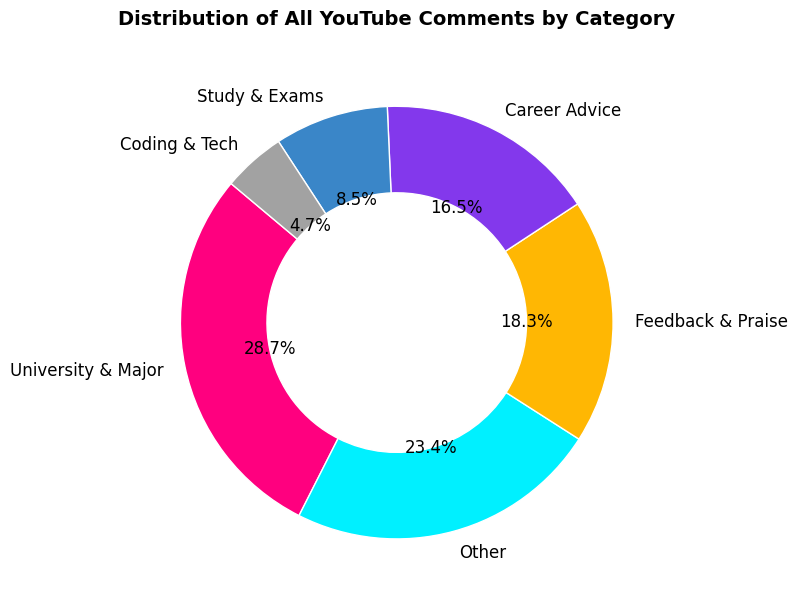

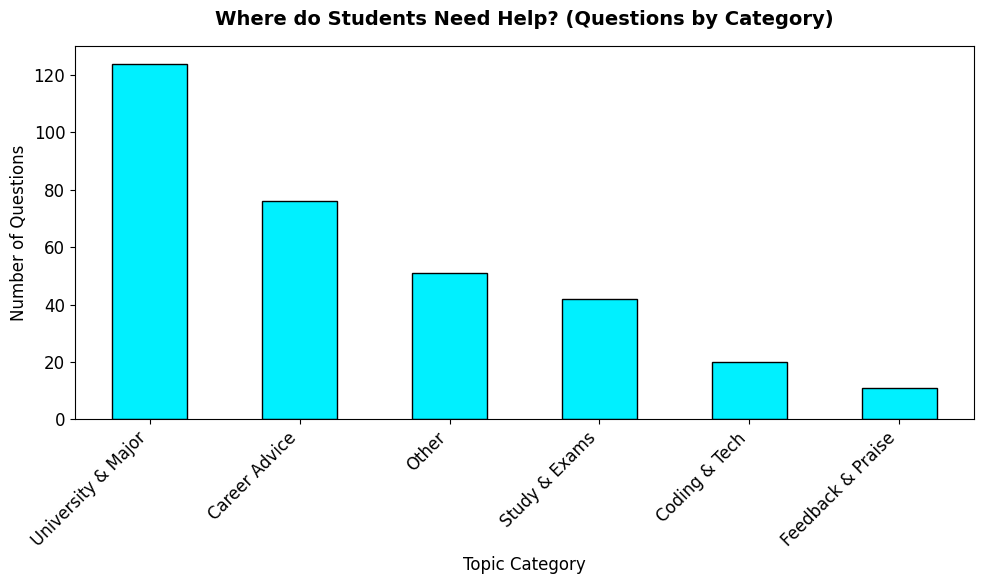

In [3]:
# Set matplotlib parameters for clean layouts
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# 1. Plot Category Distribution of All Comments
cat_counts = df["category"].value_counts()
colors = ['#ff007f', '#00f0ff', '#ffb703', '#8338ec', '#3a86c8', '#a2a2a2']
plt.figure(figsize=(8, 8))
cat_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors[:len(cat_counts)], startangle=140, wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("Distribution of All YouTube Comments by Category", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("")
plt.tight_layout()
plt.savefig("data/category_distribution_pie.png", dpi=150)
plt.show()

# 2. Plot Category Distribution of Questions Only
q_cat_counts = questions["category"].value_counts()
plt.figure(figsize=(10, 6))
q_cat_counts.plot(kind='bar', color='#00f0ff', edgecolor='black')
plt.title("Where do Students Need Help? (Questions by Category)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Topic Category", fontsize=12)
plt.ylabel("Number of Questions", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("data/questions_by_category.png", dpi=150)
plt.show()

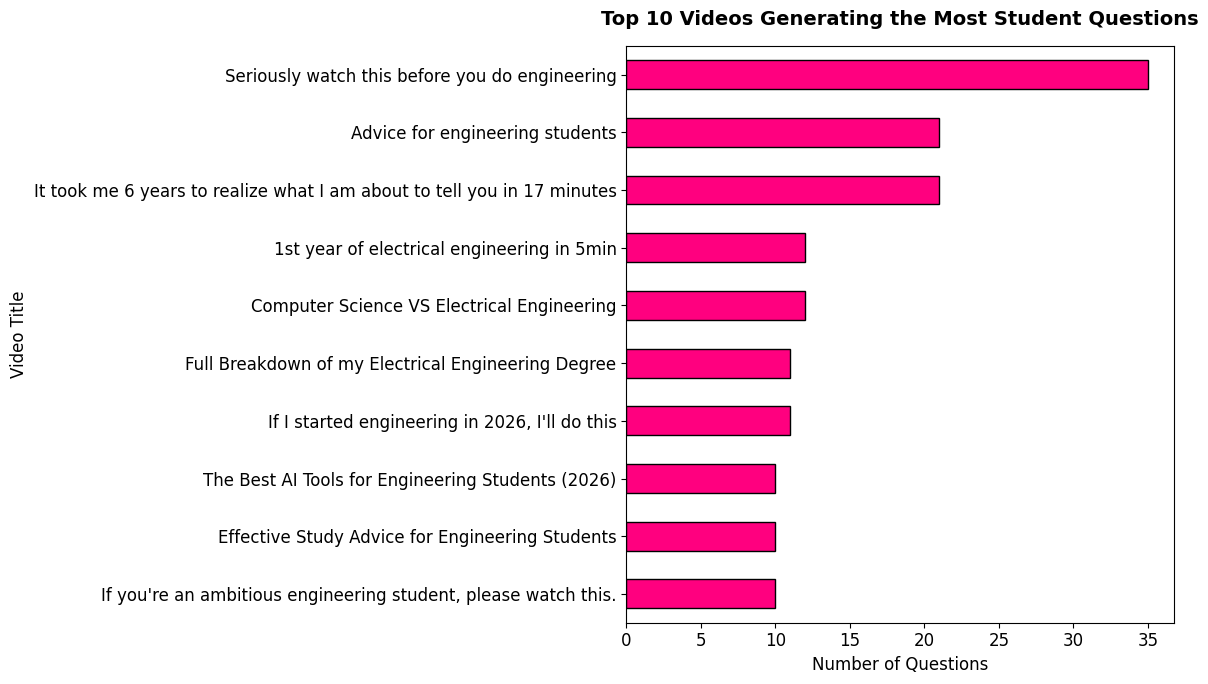

In [4]:
# 3. Plot Top 10 Videos Generating Student Questions
top_q_videos = questions["video_title"].value_counts().head(10)

plt.figure(figsize=(12, 7))
top_q_videos.plot(kind='barh', color='#ff007f', edgecolor='black')
plt.title("Top 10 Videos Generating the Most Student Questions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Questions", fontsize=12)
plt.ylabel("Video Title", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("data/top_question_videos.png", dpi=150)
plt.show()

In [5]:
# 4. Print Highly Liked Questions to understand exact phrasing
print("--- SAMPLE OF HIGHLY-LIKED STUDENT QUESTIONS ---\n")
liked_questions = questions.sort_values(by="like_count", ascending=False).head(10)
for i, row in enumerate(liked_questions.itertuples(), 1):
    print(f"{i}. Likes: {row.like_count} | Video: {row.video_title}")
    print(f"   Comment: {row.text.strip()}")
    print("-" * 80)

--- SAMPLE OF HIGHLY-LIKED STUDENT QUESTIONS ---

1. Likes: 79 | Video: It took me 6 years to realize what I am about to tell you in 17 minutes
   Comment: The question: will it be financially rewarding? The world is run by wealthy parasites who inherited money and bribed politicians
--------------------------------------------------------------------------------
2. Likes: 68 | Video: Brutally honest advice for engineering students
   Comment: Finally something feels so organic, I don't know whether you used script in front of you.., I don't know it just doesn't look any fake and heavy scripted and edited
--------------------------------------------------------------------------------
3. Likes: 21 | Video: Software vs Hardware ( Engineering)
   Comment: I'm a STEM student and i prefer handy things too cuz i believe I'm good at it. I'm happy if something I'm trying to fix physically ends up well. I know it'll be a hustle but you're right it's actually more fun. would u recommend me the 

## Research Synthesis & Key Takeaways

### 1. Topic Breakdown
* **Study & Exams:** A huge portion of questions relate directly to academic performance. Students struggle with how to study for maths, how to active recall, and how to stop taking note-taking while keeping high grades.
* **University & Major Selection:** Many questions focus on the transition into university (e.g. "is EE harder than CS?" or "what math do I need to prepare?") and course selection.
* **Career & Internships:** Job seekers want specific blueprints: how to get an internship with no experience, resume templates, and portfolio development tips.

### 2. Lifecycles of a Student (Audience Segmentation)
Based on these questions, our AI clone should categorize queries into 3 personas:
1. **The Prep / Freshman Student:** High anxiety about course load, math prerequisites, and choice of major.
2. **The Mid-Degree Student:** Needs practical productivity and study advice (exam strategies, locking in, handling tough professors).
3. **The Career Transitioner:** Needs cv/resume advice, interview preparation tips, and internship-hunting strategies.

### 3. Implications for Chatbot Architecture & Prompting
* **Tone & Personality:** The bot must match Aleks' YouTube persona: motivating, direct, structured, and action-oriented (no generic fluff).
* **Knowledge Sources:** RAG context must include transcript sections specifically targeting these three categories (Study hacks, Career strategies, Uni preparation).
* **Lead Magnet Optimization:** Since career and study hacks represent high-intent needs, prompting the student to subscribe to the newsletter to unlock these custom blueprints is a perfect alignment of value.